Iteration 100 : Loss 3627.7034
Iteration 200 : Loss 3201.0703
Iteration 300 : Loss 3045.2153
Iteration 400 : Loss 2973.3231
Iteration 500 : Loss 2938.0145
Iteration 600 : Loss 2920.0111
Iteration 700 : Loss 2910.4900
Iteration 800 : Loss 2905.2538
Iteration 900 : Loss 2902.2487
Iteration 1000 : Loss 2900.4417
Iteration 1100 : Loss 2899.2980
Iteration 1200 : Loss 2898.5328
Iteration 1300 : Loss 2897.9895
Iteration 1400 : Loss 2897.5798
Iteration 1500 : Loss 2897.2525
Iteration 1600 : Loss 2896.9769
Iteration 1700 : Loss 2896.7347
Iteration 1800 : Loss 2896.5142
Iteration 1900 : Loss 2896.3083
Iteration 2000 : Loss 2896.1122
Iteration 2100 : Loss 2895.9231
Iteration 2200 : Loss 2895.7389
Iteration 2300 : Loss 2895.5584
Iteration 2400 : Loss 2895.3808
Iteration 2500 : Loss 2895.2054
Iteration 2600 : Loss 2895.0319
Iteration 2700 : Loss 2894.8601
Iteration 2800 : Loss 2894.6897
Iteration 2900 : Loss 2894.5207
Iteration 3000 : Loss 2894.3530
Iteration 3100 : Loss 2894.1864
Iteration 3200 : 

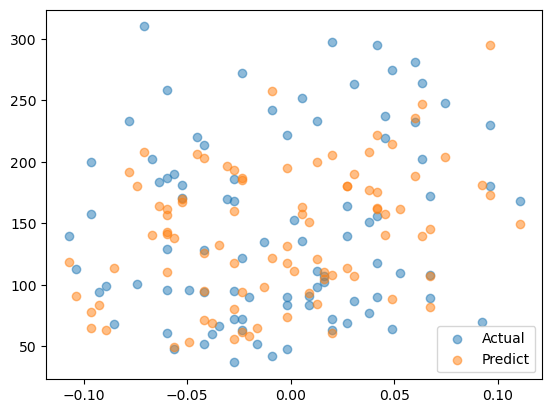

R² Score: 0.4554


In [67]:
   #프로젝트 !
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# 데이터 준비
data = load_diabetes()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 가중치 초기화
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

# 함수 정의 (행렬 연산 활용)
def model(X, W, b):
    return X.dot(W) + b

def loss(X, W, b, y):
    predictions = model(X, W, b)
    return ((predictions - y) ** 2).mean()

def gradient(X, W, b, y):
    N = len(y)
    y_pred = model(X, W, b)
    dW = (2/N) * X.T.dot(y_pred - y)
    db = 2 * (y_pred - y).mean()
    return dW, db

# 하이퍼파라미터
LEARNING_RATE = 0.77
losses = []

# 학습 루프
for i in range(1, 5001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    
    if i % 100 == 0:
        print(f'Iteration {i} : Loss {L:.4f}')

# 결과 확인
prediction = model(X_test, W, b)
plt.scatter(X_test[:, 0], y_test, label='Actual', alpha=0.5)
plt.scatter(X_test[:, 0], prediction, label='Predict', alpha=0.5)
plt.legend()
plt.show()

#R² Score :1에 가까울수록 모델이 데이터를 잘 설명함
from sklearn.metrics import r2_score
r2 = r2_score(y_test, prediction)
print(f"R² Score: {r2:.4f}")

In [1]:
 #프로젝트 2
import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [2]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

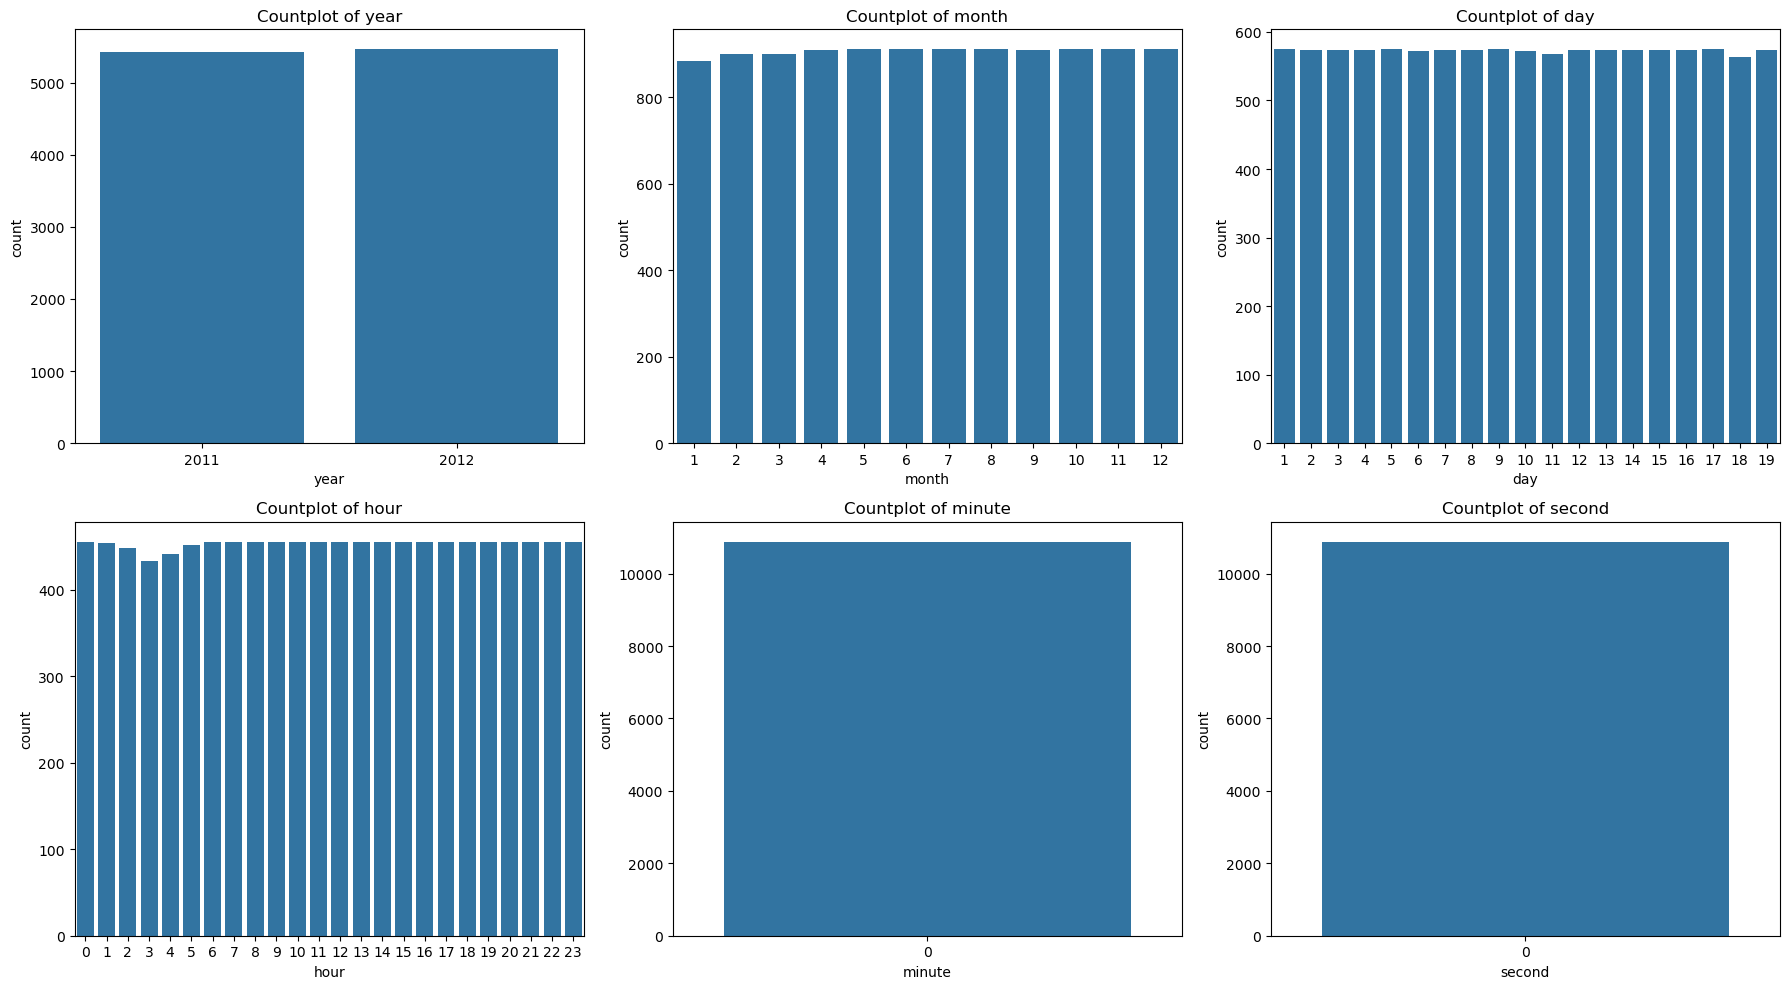

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

In [54]:
features = ['hour', 'year','month', 'day', 'temp', 'humidity','weather' ]
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [55]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19979.405628402525
RMSE: 141.34852538460572


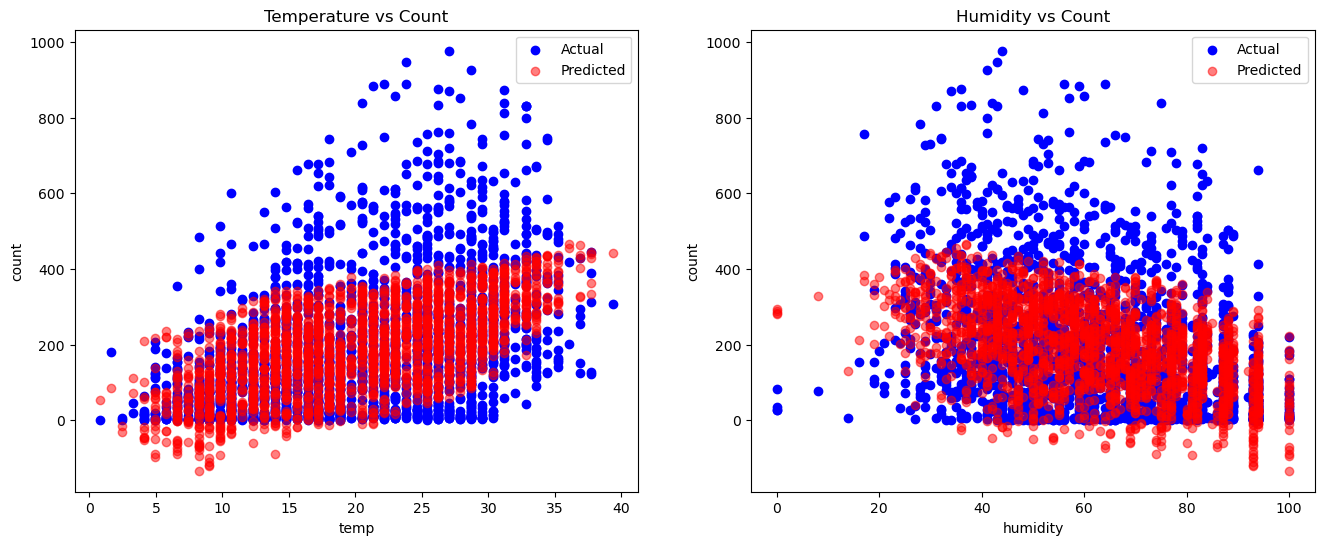

In [57]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

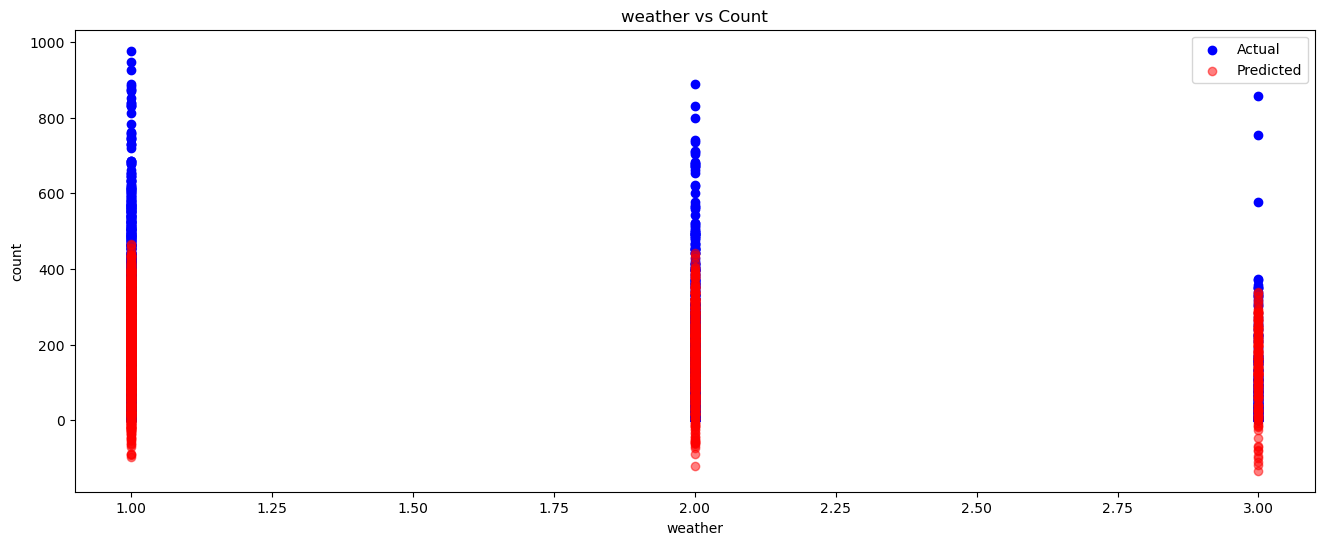

In [66]:
fig=plt.figure(figsize=(16, 6))

# temp vs count 시각화
plt.scatter(X_test['weather'], y_test, color='blue', label='Actual')
plt.scatter(X_test['weather'], y_pred, color='red', label='Predicted', alpha=0.5)
plt.xlabel('weather')
plt.ylabel('count')
plt.title('weather vs Count')
plt.legend()

